# ChatGPT Reviews Analysis

**Tools:** pandas, TextBlob, scikit-learn, seaborn, WordCloud

---


**Objectives**

| # | Objective | Method |
|---|-----------|--------|
| 1 | **Sentiment analysis** – classify reviews as positive / neutral / negative and measure how subjective they are | TextBlob polarity & subjectivity |
| 2 | **Issue identification** – find the common problems behind negative reviews | Keyword / bigram mining + issue-theme tagging |
| 3 | **Time-series analysis** – track how sentiment evolves | Monthly & weekly trend analysis |

In [1]:
# ── libraries ──────────────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── NLP libraries ───────────────────────────────────────────────────────────
from textblob import TextBlob                                  # sentiment scoring
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

# ── Global look & feel ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# One consistent colour code for the whole notebook (green / grey / red)
SENT_COLORS = {"Positive": "#2e9e6b", "Neutral": "#9aa5b1", "Negative": "#d64545"}
SENT_ORDER  = ["Positive", "Neutral", "Negative"]
RATING_PAL  = sns.color_palette("RdYlGn", 5)                   # 1★ red → 5★ green

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 3. Data Understanding & Preparation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Path to the CSV – change this if your file lives elsewhere
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/chatgpt_reviews.csv"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()          # keeping the raw frame untouched to compare before / after

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

Rows: 196,727   Columns: 4


,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to anything, it gives me tips, in gaming, studies, and life, etc. This a...",5,2024-08-23 19:20:39


In [4]:
# Structure, data types and missing values at a glance
df.info()
print("\nMissing values per column:")
print(df.isna().sum())
print(f"\nDuplicate Review Ids: {df['Review Id'].duplicated().sum():,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB

Missing values per column:
Review Id      0
Review         6
Ratings        0
Review Date    0
dtype: int64

Duplicate Review Ids: 3,573


### Cleaning steps & justification

| Step | Action | Why |
|------|--------|-----|
| 1 | Standardise column names (`snake_case`) | Consistent, easy-to-type names, no spaces |
| 2 | Fill missing reviews with `""` and flag them | Ratings without text are still valid for rating analysis, but must not be scored for sentiment |
| 3 | Convert `review_date` to `datetime` | Required for time-series work |
| 4 | Ensure `ratings` is numeric & within 1–5 | Guards against bad values |
| 5 | Drop duplicate `review_id`s | The same review captured twice would double-count it |
| 6 | Light text normalisation | Lower-case, strip URLs / extra spaces so NLP tools see consistent text |

In [5]:
# 1) Standardise column names: lower-case, spaces -> underscores
df.columns = (df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True))
print("Columns:", list(df.columns))

# 2) Missing reviews -> empty string, keep a flag so we know which rows have no text
n_missing = df["review"].isna().sum()
df["review"] = df["review"].fillna("").astype(str)
df["has_text"] = df["review"].str.strip().ne("")
print(f"Filled {n_missing} missing reviews with an empty string")

# 3) Dates -> datetime (invalid values become NaT instead of crashing)
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
print("Unparseable dates:", df["review_date"].isna().sum())

# 4) Ratings -> numeric, and verify they are in the valid 1-5 range
df["ratings"] = pd.to_numeric(df["ratings"], errors="coerce")
print("Ratings outside 1-5 or null:", (~df["ratings"].between(1, 5)).sum())
df = df[df["ratings"].between(1, 5)]
df["ratings"] = df["ratings"].astype(int)

# 5) Remove duplicate review ids
before = len(df)
df = df.drop_duplicates(subset="review_id", keep="first")
print(f"Removed {before - len(df):,} duplicate rows")

# 6) Light text normalisation (kept readable – we do NOT strip punctuation here
#    because TextBlob uses punctuation and capitalisation-free words as cues)
df["review_clean"] = (df["review"]
                      .str.lower()
                      .str.replace(r"https?://\S+|www\.\S+", " ", regex=True)   # URLs
                      .str.replace(r"\s+", " ", regex=True)                       # extra spaces
                      .str.strip())

# Helpful engineered features
df["word_count"] = df["review_clean"].str.split().str.len()
df["char_count"] = df["review_clean"].str.len()
df["month"]      = df["review_date"].dt.to_period("M").dt.to_timestamp()
df["weekday"]    = df["review_date"].dt.day_name()
df["hour"]       = df["review_date"].dt.hour

df = df.reset_index(drop=True)
print(f"\n✅ Clean dataset: {len(df):,} reviews  ({df['review_date'].min():%d %b %Y} → {df['review_date'].max():%d %b %Y})")
df.head(3)

Columns: ['review_id', 'review', 'ratings', 'review_date']
Filled 6 missing reviews with an empty string
Unparseable dates: 0
Ratings outside 1-5 or null: 0
Removed 3,573 duplicate rows

✅ Clean dataset: 193,154 reviews  (25 Jul 2023 → 23 Aug 2024)


,review_id,review,ratings,review_date,has_text,review_clean,word_count,char_count,month,weekday,hour
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,True,good,1,4,2024-08-01,Friday,19
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,True,good,1,4,2024-08-01,Friday,19
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,True,nice app,2,8,2024-08-01,Friday,19


## 4. Exploratory Data Analysis (EDA)

Let's see what the data looks like: the rating mix, review volume over time and review length.

### 4.1 Rating distribution

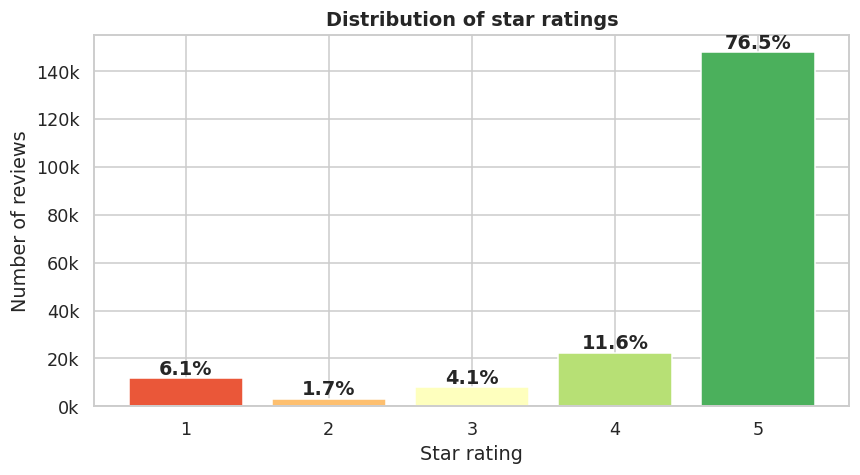

Average rating: 4.51
4-5★ share: 88.1%   |   1-2★ share: 7.8%


In [6]:
rating_counts = df["ratings"].value_counts().sort_index()
rating_pct = rating_counts / rating_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(rating_counts.index, rating_counts.values, color=RATING_PAL, edgecolor="white")
for b, p in zip(bars, rating_pct):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{p:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_title("Distribution of star ratings")
ax.set_xlabel("Star rating"); ax.set_ylabel("Number of reviews")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout(); plt.show()

print(f"Average rating: {df['ratings'].mean():.2f}")
print(f"4-5★ share: {rating_pct[[4,5]].sum():.1f}%   |   1-2★ share: {rating_pct[[1,2]].sum():.1f}%")

**Insight:** the distribution is heavily **right-skewed** – overwhelmingly 5★, with a small secondary bump at 1★. This matters: because the data is so imbalanced, the *average* rating hides the minority of unhappy users, so we will focus on the 1–2★ group when hunting for issues.

### 4.2 Review volume over time

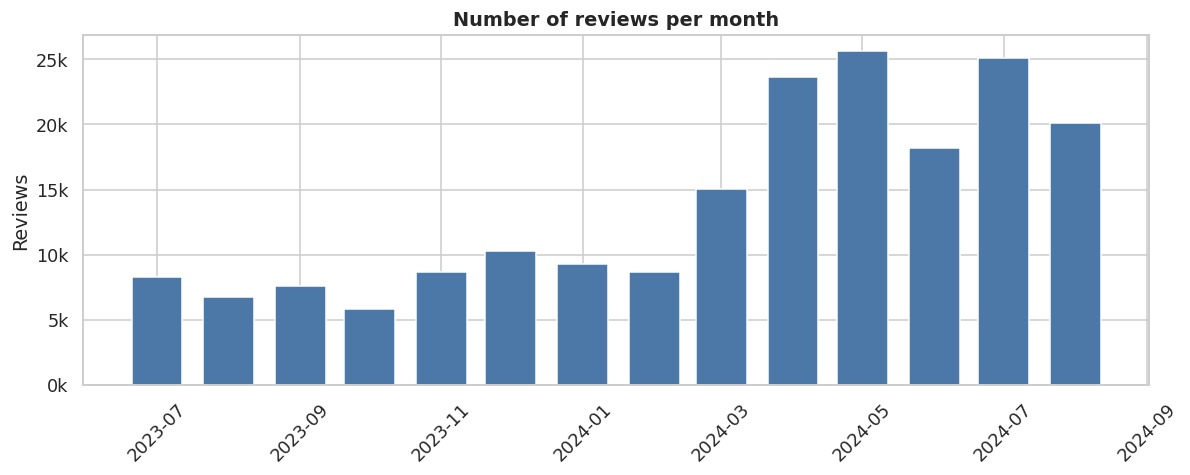

In [7]:
monthly_volume = df.groupby("month").size()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(monthly_volume.index, monthly_volume.values, width=22, color="#4c78a8")
ax.set_title("Number of reviews per month")
ax.set_ylabel("Reviews"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Insight:** review volume is not flat – it **jumps sharply from spring 2024 onward**. More reviews means more (and different) users, so we must later check whether a change in *sentiment* is just a change in *who is reviewing*.

### 4.3 Review length (and outliers)

count   193,154.000
mean          8.700
std          13.400
min           0.000
25%           2.000
50%           4.000
75%           9.000
max         134.000
Name: word_count, dtype: float64


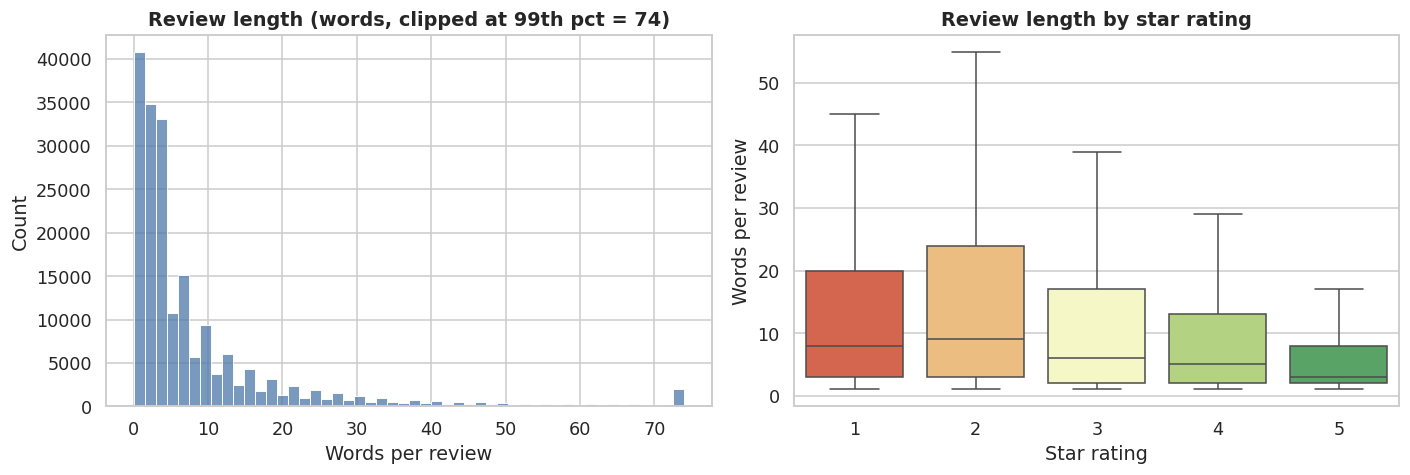

Reviews with 2 words or fewer       : 39.1%
Reviews containing non-ASCII chars  : 17.5%  (non-English text or emoji)


,median,mean
ratings,,
1,8.000,15.400
2,9.000,17.800
3,6.000,13.700
4,5.000,11.000
5,3.000,7.300


In [8]:
print(df["word_count"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram, clipped at the 99th percentile so a few very long reviews don't squash the chart
cap = df["word_count"].quantile(0.99)
sns.histplot(df["word_count"].clip(upper=cap), bins=50, color="#4c78a8", ax=axes[0])
axes[0].set_title(f"Review length (words, clipped at 99th pct = {cap:.0f})")
axes[0].set_xlabel("Words per review")

# Right: boxplot of length by star rating (log scale because of the long right tail)
sns.boxplot(data=df[df["has_text"]], x="ratings", y="word_count", palette=RATING_PAL, showfliers=False, ax=axes[1])
axes[1].set_title("Review length by star rating")
axes[1].set_xlabel("Star rating"); axes[1].set_ylabel("Words per review")
plt.tight_layout(); plt.show()

# Two facts that shape every later NLP choice
print(f"Reviews with 2 words or fewer       : {(df['word_count'] <= 2).mean()*100:.1f}%")
print(f"Reviews containing non-ASCII chars  : {df['review'].apply(lambda t: any(ord(c) > 127 for c in t)).mean()*100:.1f}%  (non-English text or emoji)")

len_by_rating = df[df["has_text"]].groupby("ratings")["word_count"].agg(["median", "mean"]).round(1)
len_by_rating

**Insight:** the typical review is very short (a handful of words, e.g. *"good"*, *"nice app"*), and **lower-rated reviews are noticeably longer** – unhappy users write more to explain what went wrong. The long right tail is *real behaviour*, not bad data (the longest review is exactly 500 characters, which points to a platform cap), so **we keep these rows** rather than removing them as outliers.

> ⚠️ **Two data-quality facts to remember:** roughly 4 in 10 reviews have just 1–2 words, and about 1 in 6 contain non-English text or emoji.

## 5. Sentiment Analysis

### 5.1 Method: why TextBlob?
* **Polarity** ∈ [-1, +1] – how negative → positive the language is.
* **Subjectivity** ∈ [0, 1] – 0 = objective / factual, 1 = personal opinion.
* TextBlob is a **lexicon-based** model: fast, transparent and needs no training data – ideal for ~190k short reviews and easy to explain in a demo.
* **Limitation:** it can miss sarcasm, negation in long sentences and domain slang. That is why we **validate it against the star ratings** (which act as our "ground truth").

**Classification rule:** polarity > 0.05 → Positive, < −0.05 → Negative, otherwise Neutral (a small dead-zone avoids labelling near-zero scores as polar).

In [9]:
# Score every review that has text. Empty reviews stay NaN (no text -> no sentiment).
def get_sentiment(text):
    """Return (polarity, subjectivity) for a piece of text."""
    s = TextBlob(text).sentiment
    return s.polarity, s.subjectivity

scores = df.loc[df["has_text"], "review_clean"].apply(get_sentiment)
df.loc[df["has_text"], "polarity"]     = scores.str[0]
df.loc[df["has_text"], "subjectivity"] = scores.str[1]

def label_polarity(p, threshold=0.05):
    """Map a polarity score to a sentiment category."""
    if pd.isna(p):       return np.nan
    if p >  threshold:   return "Positive"
    if p < -threshold:   return "Negative"
    return "Neutral"

df["sentiment"] = df["polarity"].apply(label_polarity)

# Rating-based label = what the user *told us* with stars (4-5 positive, 3 neutral, 1-2 negative)
df["rating_sentiment"] = pd.cut(df["ratings"], bins=[0, 2, 3, 5], labels=["Negative", "Neutral", "Positive"])

df[["review", "ratings", "polarity", "subjectivity", "sentiment"]].sample(8, random_state=7)

,review,ratings,polarity,subjectivity,sentiment
76663,good,5,0.700,0.600,Positive
162513,٠..,5,0.000,0.000,Neutral
122871,Every time I try to use it pops up error try later,2,0.000,0.000,Neutral
15852,🤍,5,0.000,0.000,Neutral
44926,great,5,0.800,0.750,Positive
131436,It's great to have chat GPT in application.,4,0.800,0.750,Positive
189279,Good,5,0.700,0.600,Positive
142462,Provide wrong maths calculation,1,-0.500,0.900,Negative


### 5.2 Overall sentiment distribution

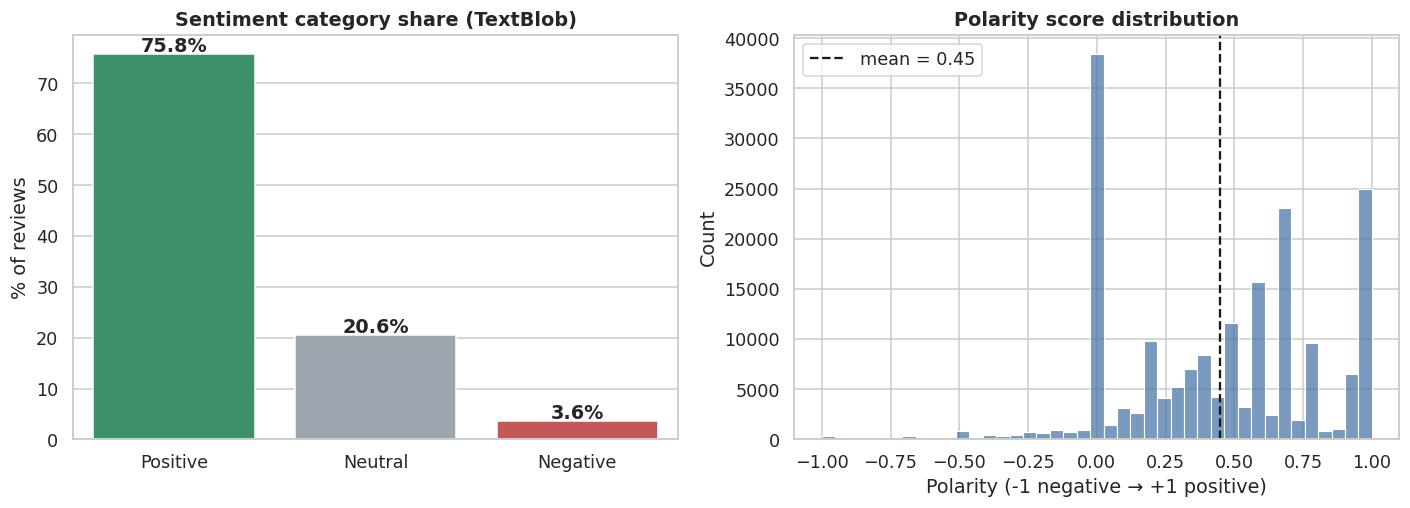

In [10]:
text_df = df[df["has_text"]].copy()          # all sentiment work uses reviews that actually contain text

sent_share = text_df["sentiment"].value_counts(normalize=True).reindex(SENT_ORDER) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: how many reviews in each class
sns.barplot(x=sent_share.index, y=sent_share.values, palette=SENT_COLORS, order=SENT_ORDER, ax=axes[0])
for i, v in enumerate(sent_share.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
axes[0].set_title("Sentiment category share (TextBlob)")
axes[0].set_ylabel("% of reviews"); axes[0].set_xlabel("")

# Right: full polarity histogram – reveals the clusters behind the categories
sns.histplot(text_df["polarity"], bins=41, color="#4c78a8", ax=axes[1])
axes[1].axvline(text_df["polarity"].mean(), color="k", ls="--", label=f"mean = {text_df['polarity'].mean():.2f}")
axes[1].set_title("Polarity score distribution")
axes[1].set_xlabel("Polarity (-1 negative → +1 positive)")
axes[1].legend()
plt.tight_layout(); plt.show()

**Reading the chart:** the polarity histogram has distinct *spikes* (e.g. near 0 and around +0.5 to +0.7). That's an artefact of the many one-word reviews: *"good"* (0.7), *"nice"* (0.6), *"great"* (0.8) each map to a fixed score, while the big spike at 0 comes from emoji-only, non-English and purely factual reviews. It is a good reminder that this is a **short-text** dataset.

### 5.3 Sentiment vs. star ratings (validating the model)

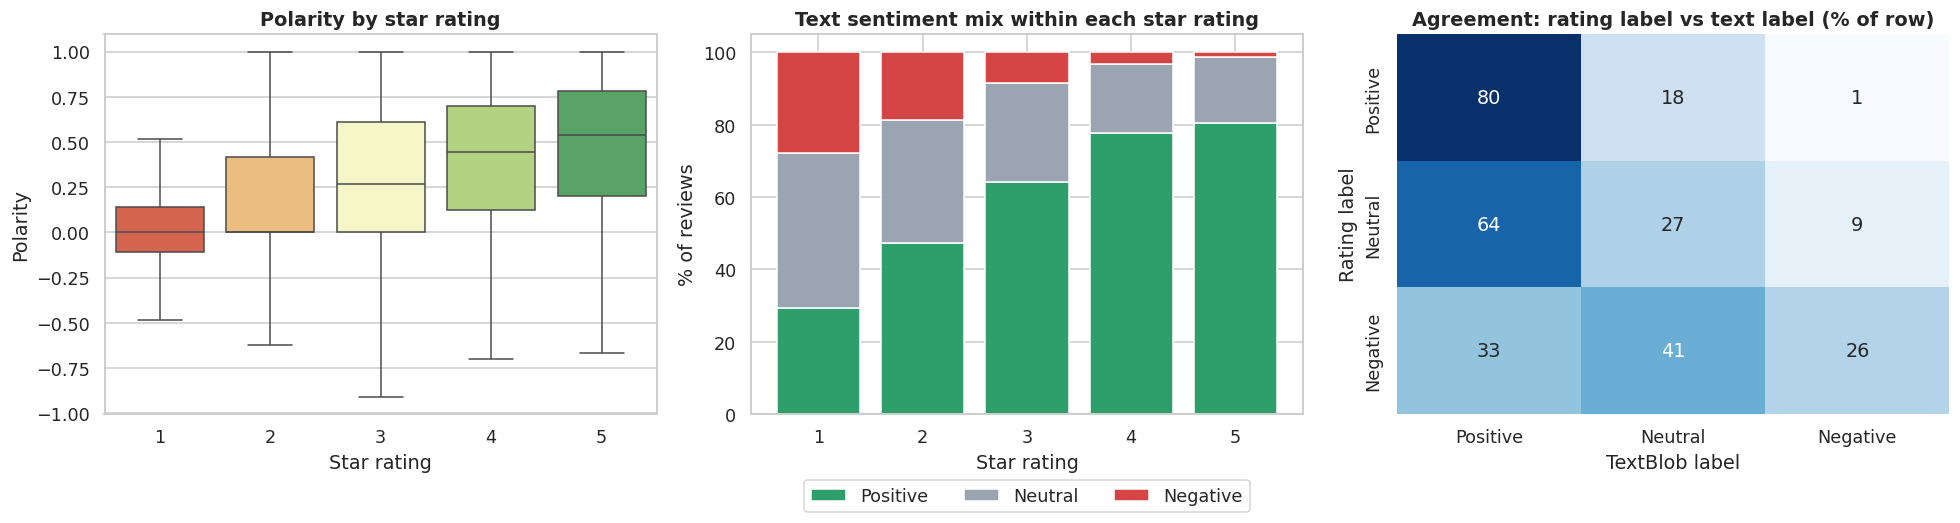

Spearman correlation (rating vs polarity): 0.25
Exact label agreement (rating vs text):     73.7%

Average polarity by rating:
ratings
1   0.013
2   0.161
3   0.308
4   0.426
5   0.500
Name: polarity, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Polarity distribution per star rating
sns.boxplot(data=text_df, x="ratings", y="polarity", palette=RATING_PAL, showfliers=False, ax=axes[0])
axes[0].set_title("Polarity by star rating")
axes[0].set_xlabel("Star rating"); axes[0].set_ylabel("Polarity")

# (b) Sentiment mix inside each star rating (100% stacked)
mix = (pd.crosstab(text_df["ratings"], text_df["sentiment"], normalize="index")[SENT_ORDER] * 100)
mix.plot(kind="bar", stacked=True, color=[SENT_COLORS[c] for c in SENT_ORDER], ax=axes[1], width=0.8)
axes[1].set_title("Text sentiment mix within each star rating")
axes[1].set_xlabel("Star rating"); axes[1].set_ylabel("% of reviews"); axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)

# (c) Agreement matrix: rating-based label (rows) vs text-based label (columns)
agree = pd.crosstab(text_df["rating_sentiment"], text_df["sentiment"], normalize="index")[SENT_ORDER].loc[SENT_ORDER] * 100
sns.heatmap(agree, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set_title("Agreement: rating label vs text label (% of row)")
axes[2].set_xlabel("TextBlob label"); axes[2].set_ylabel("Rating label")
plt.tight_layout(); plt.show()

# Quantify the relationship
corr = text_df[["ratings", "polarity"]].corr(method="spearman").iloc[0, 1]
accuracy = (text_df["rating_sentiment"].astype(str) == text_df["sentiment"]).mean() * 100
print(f"Spearman correlation (rating vs polarity): {corr:.2f}")
print(f"Exact label agreement (rating vs text):     {accuracy:.1f}%")
print("\nAverage polarity by rating:")
print(text_df.groupby("ratings")["polarity"].mean().round(3))

**Interpretation:**
* Polarity **does rise with star rating** (average ≈ 0.01 at 1★ → 0.50 at 5★), so the model is directionally valid.
* But the link is **only moderate** (Spearman ≈ 0.25) and agreement with the star-based label is ≈ 74%, driven almost entirely by the huge positive class.
* **TextBlob struggles with negatives:** only about a quarter of 1–2★ reviews are labelled negative; the rest are neutral or even positive. Complaints are usually *factual* ("error, try later", "can't sign in") and contain no sentiment words, so a lexicon scores them as 0.
* **Implication:** use TextBlob for *tone and intensity*, but use the **star rating to decide which reviews are complaints** when hunting for issues (that is what Section 7 does).

### 5.4 When stars and text disagree

In [12]:
# Reviews where the star rating and text tone clearly clash – a quick way to spot sarcasm,
# mis-clicked ratings and model blind spots.
happy_stars_angry_text = text_df[(text_df["ratings"] == 5) & (text_df["polarity"] < -0.3)]
angry_stars_happy_text = text_df[(text_df["ratings"] == 1) & (text_df["polarity"] > 0.5)]

print(f"5★ reviews with clearly negative text : {len(happy_stars_angry_text):,}  "
      f"({len(happy_stars_angry_text)/ (text_df['ratings']==5).sum()*100:.2f}% of all 5★)")
print(f"1★ reviews with clearly positive text : {len(angry_stars_happy_text):,}  "
      f"({len(angry_stars_happy_text)/ (text_df['ratings']==1).sum()*100:.2f}% of all 1★)")

print("\n— 5★ but negative wording —")
display(happy_stars_angry_text[["review", "polarity"]].sample(5, random_state=1))
print("— 1★ but positive wording —")
display(angry_stars_happy_text[["review", "polarity"]].sample(5, random_state=1))

5★ reviews with clearly negative text : 647  (0.44% of all 5★)
1★ reviews with clearly positive text : 1,344  (11.45% of all 1★)

— 5★ but negative wording —


,review,polarity
126378,To much bad and poty,-0.700
140041,fake app don't install,-0.500
187367,ChatGPT es una potente aplicación de inteligencia artificial desarrollada por OpenAI. Utilizando la arquitectura GPT...,-0.600
121998,unbelievable app! This app is out of this world!!!,-0.610
147347,idk just boring,-1.000


— 1★ but positive wording —


,review,polarity
117989,won't render controversial Easter memes,0.550
176568,amazing app,0.600
11223,best app chatgpt so thanx,1.000
60502,It is a good app for students 😍😍,0.700
182201,good,0.700


**Takeaway:** the two kinds of mismatch behave very differently.
* **5★ with negative text** is rare (< 0.5% of 5★ reviews). Reading them, it is mostly slang or odd wording ("*unbelievable app!*"), non-English text and the model reading words like "bad" or "boring" out of context.
* **1★ with clearly positive text** is far more common (≈ 11% of 1★ reviews). Many of these look like **mis-tapped stars** (e.g. "*amazing app*", "*best app*" with 1★) or praise followed by a complaint. This is a reminder that star ratings are noisy too, and a good argument for combining both signals.

### 5.5 Subjectivity – how opinionated are users?

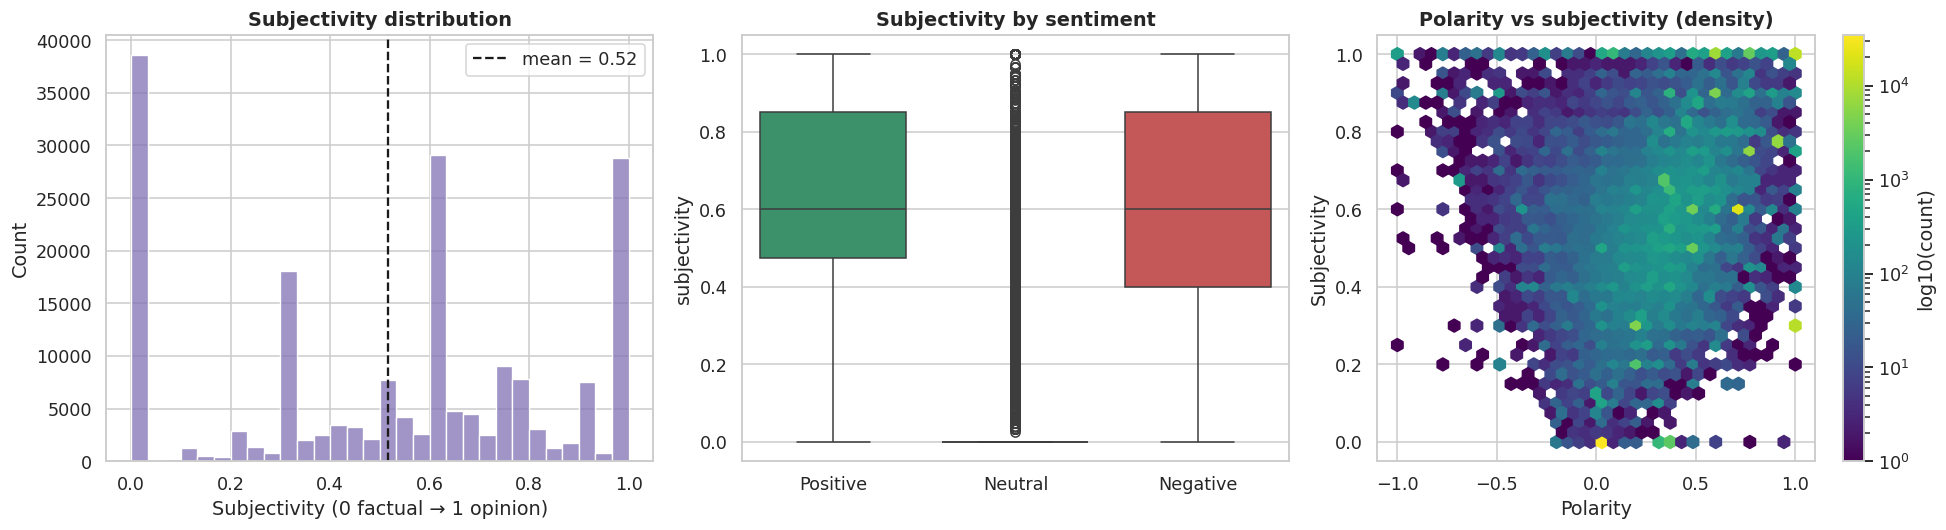

Mean subjectivity by sentiment class:
sentiment
Positive   0.638
Neutral    0.057
Negative   0.605
Name: subjectivity, dtype: float64

Share of reviews that are mostly opinion (subjectivity > 0.5): 56.8%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Overall subjectivity distribution
sns.histplot(text_df["subjectivity"], bins=30, color="#8172b3", ax=axes[0])
axes[0].axvline(text_df["subjectivity"].mean(), color="k", ls="--", label=f"mean = {text_df['subjectivity'].mean():.2f}")
axes[0].set_title("Subjectivity distribution"); axes[0].set_xlabel("Subjectivity (0 factual → 1 opinion)"); axes[0].legend()

# (b) Subjectivity by sentiment class
sns.boxplot(data=text_df, x="sentiment", y="subjectivity", order=SENT_ORDER, palette=SENT_COLORS, ax=axes[1])
axes[1].set_title("Subjectivity by sentiment"); axes[1].set_xlabel("")

# (c) Polarity vs subjectivity density – shows how strong sentiment and opinion go together
hb = axes[2].hexbin(text_df["polarity"], text_df["subjectivity"], gridsize=35, cmap="viridis", bins="log", mincnt=1)
axes[2].set_title("Polarity vs subjectivity (density)")
axes[2].set_xlabel("Polarity"); axes[2].set_ylabel("Subjectivity")
plt.colorbar(hb, ax=axes[2], label="log10(count)")
plt.tight_layout(); plt.show()

print("Mean subjectivity by sentiment class:")
print(text_df.groupby("sentiment")["subjectivity"].mean().reindex(SENT_ORDER).round(3))
print(f"\nShare of reviews that are mostly opinion (subjectivity > 0.5): {(text_df['subjectivity'] > 0.5).mean()*100:.1f}%")

**Interpretation:** subjectivity is almost mechanically tied to polarity here. Positive and negative reviews both average ≈ 0.6 subjectivity, while neutral reviews average ≈ 0.06 (factual or no text signal at all). Strong sentiment words ("love", "worst") are opinions by definition, so subjectivity mostly tells us whether a review expresses **an opinion or states a fact**, and complements polarity's direction. About 57% of reviews are mostly opinion.

## 6. Text Analysis – What do happy users say?

**Approach:** take *positively rated* reviews (4–5★), remove stop-words, and count the most common single words (**unigrams**) and two-word phrases (**bigrams**).
Using star rating (rather than TextBlob) to define "positive" avoids circularity: we are finding the words that *co-occur with satisfaction*, not words the sentiment lexicon already scores.

In [14]:
# ── Stop-words: sklearn's English list + domain words that carry no insight ──
DOMAIN_STOPWORDS = {"app", "apps", "chatgpt", "chat", "gpt", "openai", "ai", "really", "just", "like", "use",
                    "using", "used", "im", "ive", "dont", "doesnt", "cant", "it", "its", "one", "get", "got",
                    "also", "much", "even", "will", "would", "can", "ca", "make", "lot"}
STOPWORDS = list(ENGLISH_STOP_WORDS.union(DOMAIN_STOPWORDS))

# Negations are meaningful in phrases ("doesnt work", "cant login"), so we keep them for bigrams
NEGATIONS = {"not", "no", "never", "cant", "cannot", "dont", "doesnt", "didnt", "wont", "isnt", "wasnt", "couldnt"}
STOPWORDS_BIGRAM = [w for w in STOPWORDS if w not in NEGATIONS]

def top_terms(texts, ngram=(1, 1), top_n=20, min_df=5):
    """Return the top_n most frequent n-grams in `texts` as a DataFrame (term, count)."""
    texts = texts.str.replace(r"['’]", "", regex=True)         # "doesn't" -> "doesnt" (stops it splitting into "doesn" + "t")
    vec = CountVectorizer(stop_words=STOPWORDS if ngram == (1, 1) else STOPWORDS_BIGRAM, ngram_range=ngram, min_df=min_df,
                          token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b")   # alphabetic tokens of 2+ letters
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    out = pd.DataFrame({"term": vec.get_feature_names_out(), "count": counts})
    return out.sort_values("count", ascending=False).head(top_n).reset_index(drop=True)

# Filter: positively rated reviews that actually contain text
pos_reviews = text_df.loc[text_df["ratings"] >= 4, "review_clean"]
print(f"Positively rated (4-5★) reviews analysed: {len(pos_reviews):,}")

pos_uni = top_terms(pos_reviews, ngram=(1, 1), top_n=25)
pos_bi  = top_terms(pos_reviews, ngram=(2, 2), top_n=25)

Positively rated (4-5★) reviews analysed: 170,230


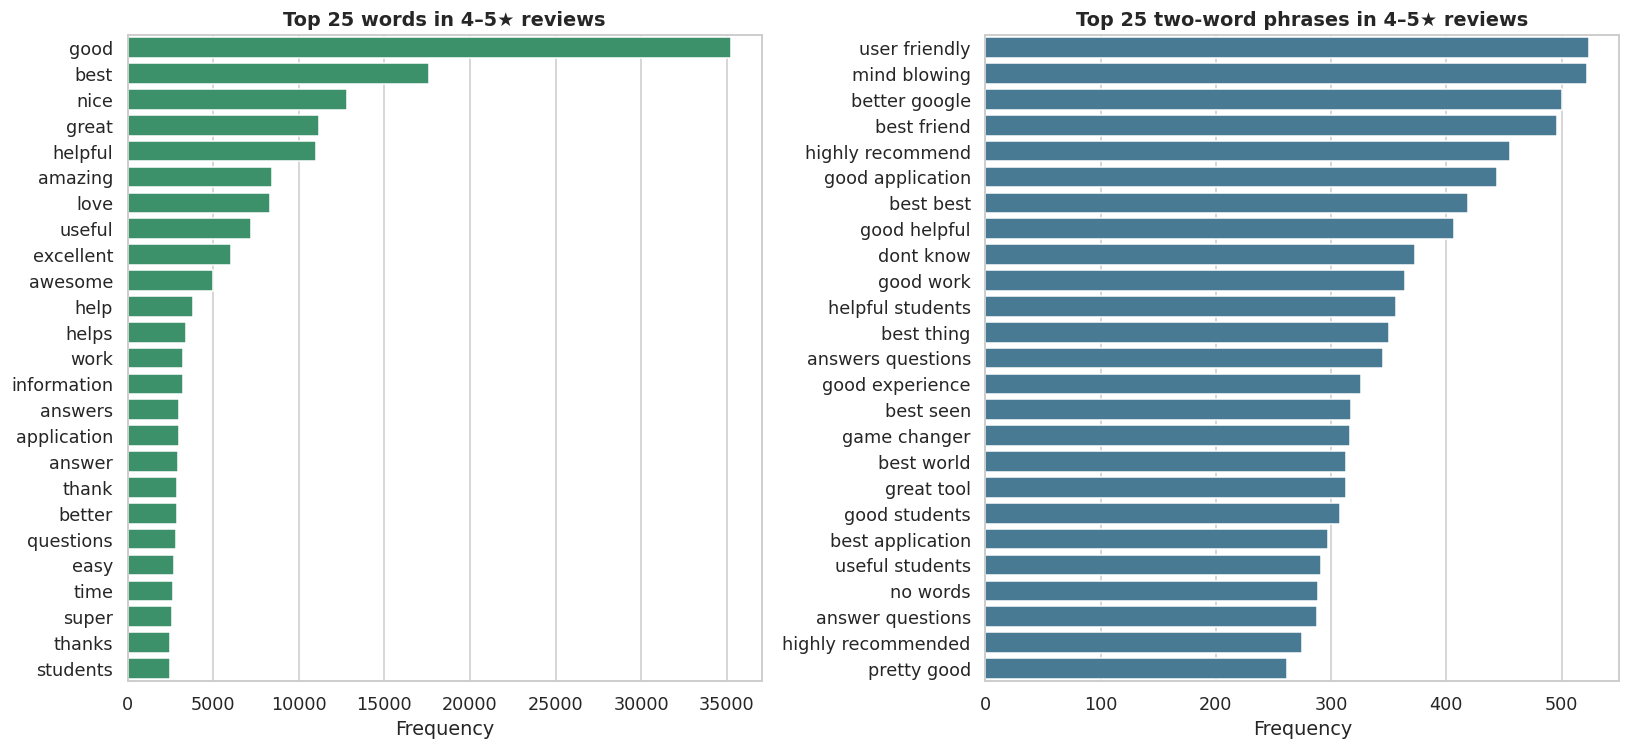

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.barplot(data=pos_uni, y="term", x="count", color=SENT_COLORS["Positive"], ax=axes[0])
axes[0].set_title("Top 25 words in 4–5★ reviews"); axes[0].set_xlabel("Frequency"); axes[0].set_ylabel("")
sns.barplot(data=pos_bi, y="term", x="count", color="#3b7ea1", ax=axes[1])
axes[1].set_title("Top 25 two-word phrases in 4–5★ reviews"); axes[1].set_xlabel("Frequency"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

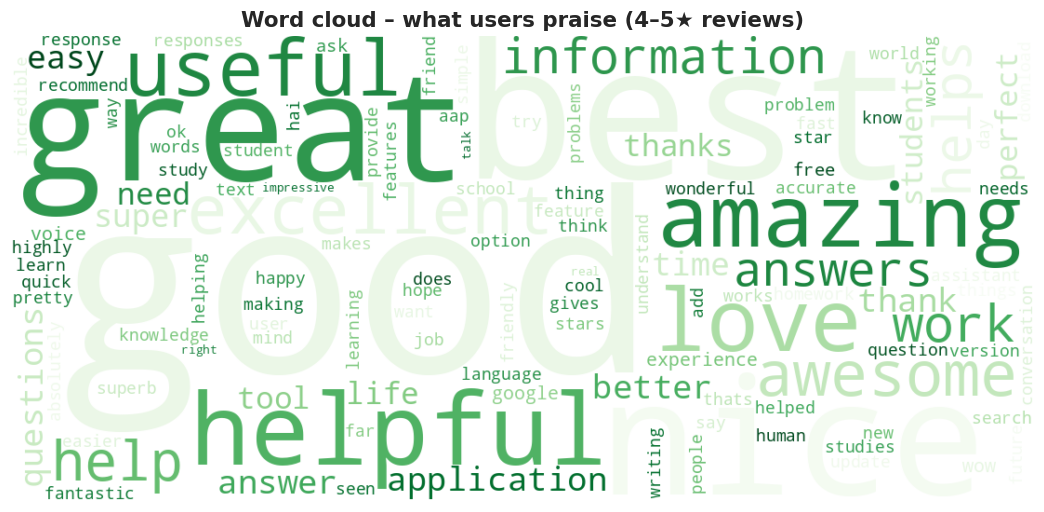

In [16]:
# Word cloud built from word frequencies (bigger = more frequent)
freqs = top_terms(pos_reviews, ngram=(1, 1), top_n=150).set_index("term")["count"].to_dict()
wc = WordCloud(width=1100, height=500, background_color="white", colormap="Greens",
               max_words=120, random_state=42).generate_from_frequencies(freqs)

plt.figure(figsize=(12, 5.5))
plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
plt.title("Word cloud – what users praise (4–5★ reviews)", fontsize=14, fontweight="bold")
plt.show()

### 6.1 Which *aspects* do users praise?
Raw word counts are dominated by generic praise ("good", "great", "nice"). To get to **product features**, we group words into aspects and measure how many positive reviews mention each one.

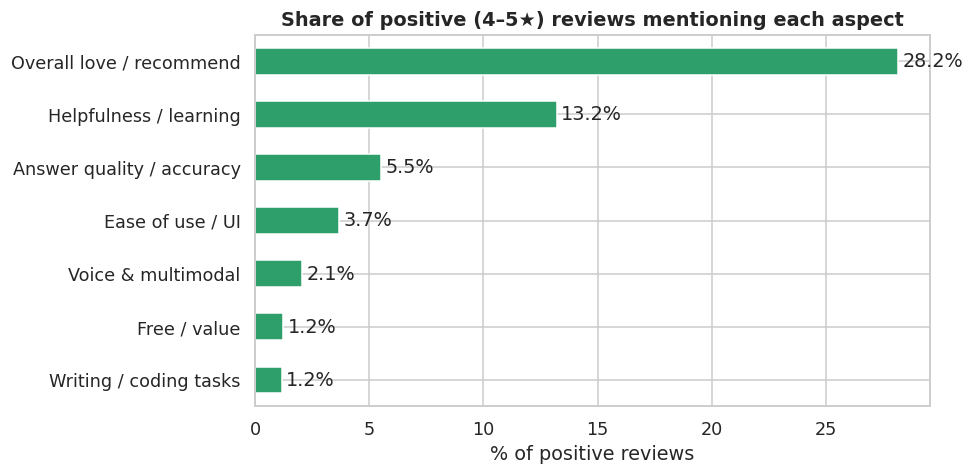

In [17]:
# Aspect dictionary: aspect name -> regex of words that signal it
POSITIVE_ASPECTS = {
    "Helpfulness / learning":   r"\b(help|helps|helpful|helped|learn|learning|study|studying|homework|education|school|student)\b",
    "Answer quality / accuracy": r"\b(accurate|accuracy|smart|intelligent|answers?|knowledge|informative|correct|precise)\b",
    "Ease of use / UI":          r"\b(easy|simple|user friendly|interface|convenient|fast|quick|smooth)\b",
    "Writing / coding tasks":    r"\b(writing|write|essay|code|coding|programming|email|translate|translation)\b",
    "Voice & multimodal":        r"\b(voice|speak|speech|image|images|photo|camera|vision|4o)\b",
    "Overall love / recommend":  r"\b(love|amazing|awesome|excellent|best|fantastic|wonderful|recommend|perfect)\b",
    "Free / value":              r"\b(free|worth|value)\b",
}

aspect_share = pd.Series({a: pos_reviews.str.contains(rx, regex=True).mean() * 100
                          for a, rx in POSITIVE_ASPECTS.items()}).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
aspect_share.plot(kind="barh", color=SENT_COLORS["Positive"], ax=ax)
for i, v in enumerate(aspect_share.values):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center")
ax.set_title("Share of positive (4–5★) reviews mentioning each aspect")
ax.set_xlabel("% of positive reviews")
plt.tight_layout(); plt.show()

## 7. Issue Identification – What frustrates users?

Positive reviews tell us what to protect; **negative reviews tell us what to fix.**
We take **1–2★ reviews** and (a) find the words that are *over-represented* compared with happy reviews, then (b) tag each complaint with an issue theme.

### 7.1 Words that separate unhappy from happy users
Frequency alone is misleading ("app" appears everywhere), so we use a **log-odds ratio**: how much more likely is a word to appear in a negative review than a positive one?

Negative (1-2★) reviews analysed: 15,007


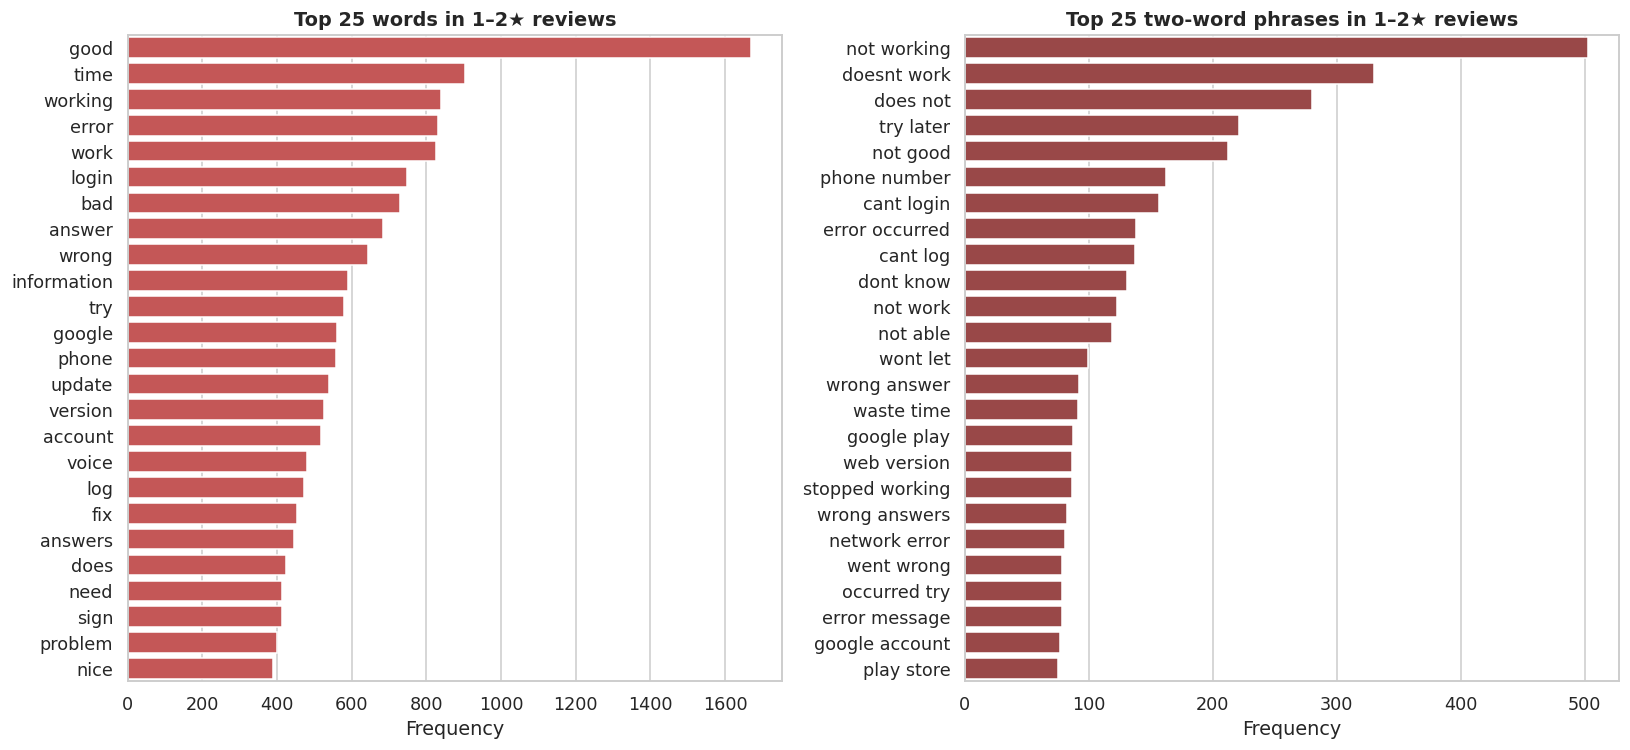

In [18]:
neg_reviews = text_df.loc[text_df["ratings"] <= 2, "review_clean"]
print(f"Negative (1-2★) reviews analysed: {len(neg_reviews):,}")

# Top raw terms in negative reviews
neg_uni = top_terms(neg_reviews, ngram=(1, 1), top_n=25)
neg_bi  = top_terms(neg_reviews, ngram=(2, 2), top_n=25)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.barplot(data=neg_uni, y="term", x="count", color=SENT_COLORS["Negative"], ax=axes[0])
axes[0].set_title("Top 25 words in 1–2★ reviews"); axes[0].set_xlabel("Frequency"); axes[0].set_ylabel("")
sns.barplot(data=neg_bi, y="term", x="count", color="#a63a3a", ax=axes[1])
axes[1].set_title("Top 25 two-word phrases in 1–2★ reviews"); axes[1].set_xlabel("Frequency"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

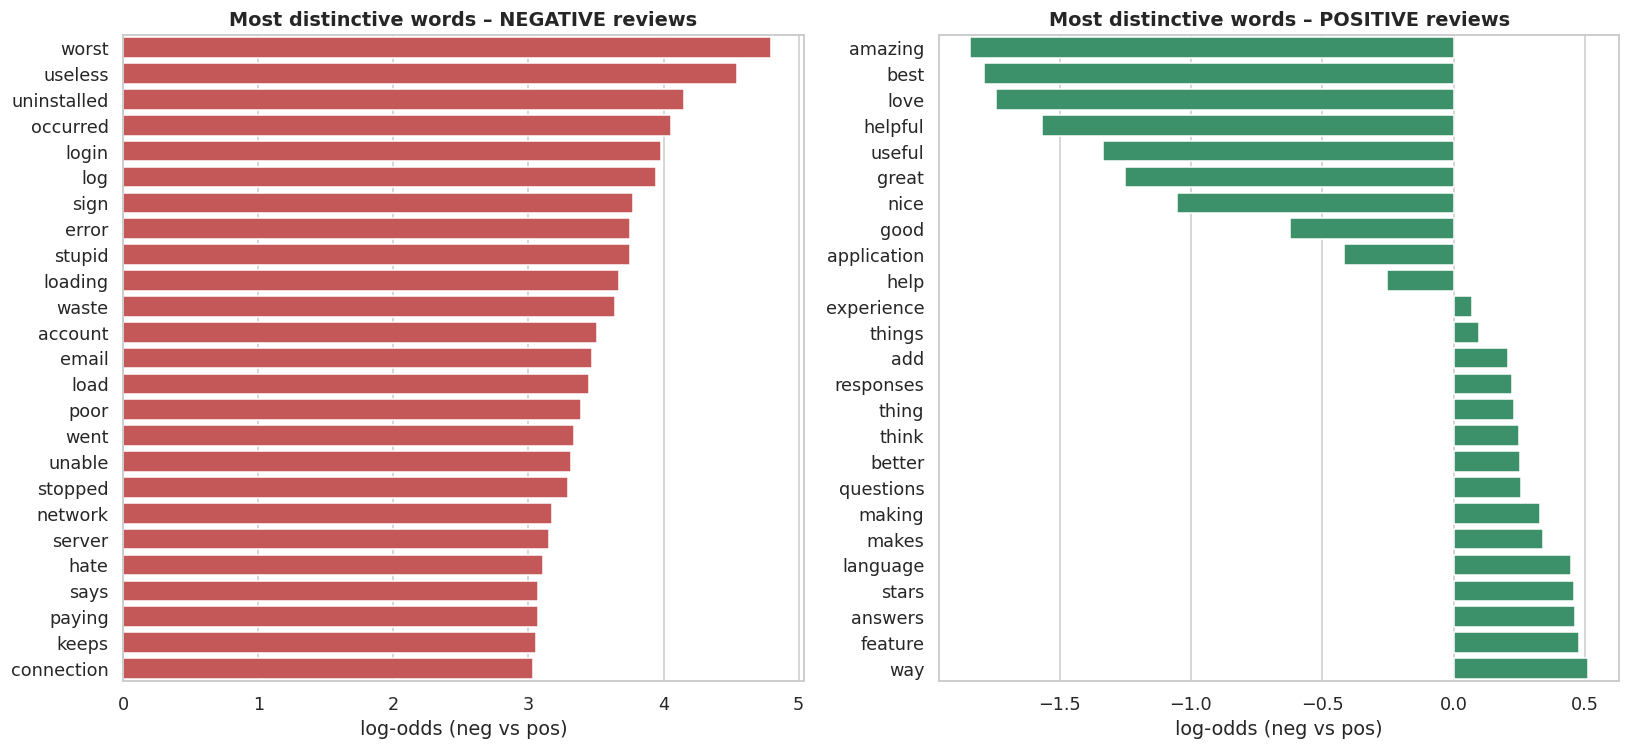

In [19]:
# Log-odds: which words are most distinctive of NEGATIVE vs POSITIVE reviews?
vec = CountVectorizer(stop_words=STOPWORDS, binary=True, min_df=50,          # binary -> "does the review contain the word?"
                      token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b")
strip_apos = lambda t: t.str.replace(r"['’]", "", regex=True)   # same contraction handling as top_terms()
X_neg = vec.fit_transform(strip_apos(neg_reviews))
X_pos = vec.transform(strip_apos(pos_reviews))

neg_df_ = np.asarray(X_neg.sum(axis=0)).ravel() + 1          # +1 smoothing avoids division by zero
pos_df_ = np.asarray(X_pos.sum(axis=0)).ravel() + 1
log_odds = np.log((neg_df_ / (len(neg_reviews) + 2)) / (pos_df_ / (len(pos_reviews) + 2)))

lo = pd.DataFrame({"term": vec.get_feature_names_out(), "log_odds": log_odds, "neg_reviews": neg_df_ - 1})
lo = lo[lo["neg_reviews"] >= 100]                            # ignore rare words

top_neg_terms = lo.sort_values("log_odds", ascending=False).head(25)
top_pos_terms = lo.sort_values("log_odds").head(25)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.barplot(data=top_neg_terms, y="term", x="log_odds", color=SENT_COLORS["Negative"], ax=axes[0])
axes[0].set_title("Most distinctive words – NEGATIVE reviews"); axes[0].set_xlabel("log-odds (neg vs pos)"); axes[0].set_ylabel("")
sns.barplot(data=top_pos_terms, y="term", x="log_odds", color=SENT_COLORS["Positive"], ax=axes[1])
axes[1].set_title("Most distinctive words – POSITIVE reviews"); axes[1].set_xlabel("log-odds (neg vs pos)"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

### 7.2 Tagging complaints with issue themes
Each negative review is checked against keyword patterns for common problem areas. One review can mention several themes, so percentages add to more than 100%.

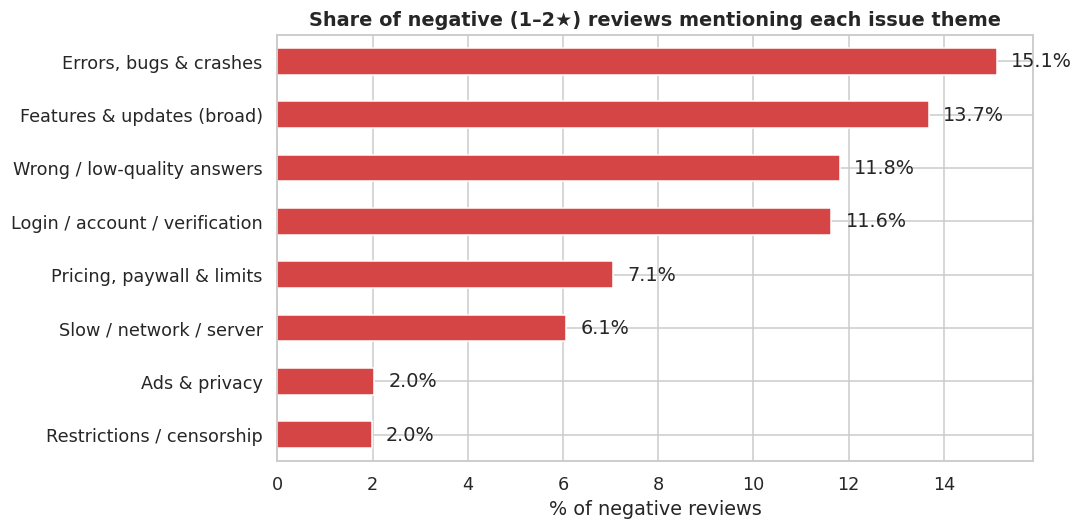

Negative reviews matched by at least one theme: 48.6%
→ The rest are mostly very short / generic ('bad', 'worst app') with no specific cause.


In [20]:
# Issue dictionary: theme -> regex. Built by reading the top negative words/bigrams above.
ISSUE_THEMES = {
    "Errors, bugs & crashes":       r"\b(error|errors|bug|bugs|buggy|glitch|glitches|crash|crashes|crashing|freez\w*|froze|stuck|not working|doesn.t work|won.t work|not opening|won.t open|something went wrong|fix)\b",
    "Login / account / verification": r"\b(login|log in|logged|sign in|signin|sign up|account|verify|verification|password|phone number|banned|otp|code)\b",
    "Slow / network / server":      r"\b(slow|loading|lag|laggy|network|server|servers|down|connection|internet|timeout|wait|waiting)\b",
    "Pricing, paywall & limits":    r"\b(pay|paid|payment|subscription|subscribe|premium|plus|money|price|refund|charge|charged|expensive|limit|limits|limited|credits?)\b",
    "Wrong / low-quality answers":  r"\b(wrong|incorrect|inaccurate|mistake|mistakes|false|nonsense|useless|worst|worse|terrible|dumb|stupid|hallucinat\w*|made up|lies|lying)\b",
    "Restrictions / censorship":    r"\b(restrict\w*|censor\w*|filter\w*|policy|refuse\w*|can.t answer|cannot answer|not allowed|blocked|guidelines)\b",
    "Features & updates (broad)":   r"\b(voice|mic|microphone|image|images|photo|upload|history|delete|update|updated|feature|features|version)\b",
    "Ads & privacy":                r"\b(ads?|advert\w*|privacy|data|spam|tracking)\b",
}

neg_df = text_df[text_df["ratings"] <= 2].copy()
for theme, rx in ISSUE_THEMES.items():
    neg_df[theme] = neg_df["review_clean"].str.contains(rx, regex=True)

neg_df["any_theme"] = neg_df[list(ISSUE_THEMES)].any(axis=1)
issue_share = (neg_df[list(ISSUE_THEMES)].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
issue_share.plot(kind="barh", color=SENT_COLORS["Negative"], ax=ax)
for i, v in enumerate(issue_share.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
ax.set_title("Share of negative (1–2★) reviews mentioning each issue theme")
ax.set_xlabel("% of negative reviews")
plt.tight_layout(); plt.show()

print(f"Negative reviews matched by at least one theme: {neg_df['any_theme'].mean()*100:.1f}%")
print("→ The rest are mostly very short / generic ('bad', 'worst app') with no specific cause.")

In [21]:
# Read real examples for each theme – great evidence to quote in the demo
for theme in list(issue_share.index[::-1][:5]):
    print(f"\n━━ {theme} ━━")
    ex = neg_df[neg_df[theme] & (neg_df["word_count"].between(8, 40))]["review"].sample(3, random_state=3)
    for t in ex:
        print("  •", t)


━━ Errors, bugs & crashes ━━
  • When I record in the English language, the app writes it in Arabic." Please fix it.
  • Chat gpt is not working even when I have data
  • I think there are some technical problem. So,chatgpt is not working.

━━ Features & updates (broad) ━━
  • This app is the best app but in apps image it show picture in reality it did not show any picture.
  • Why don't update this AI. Ai just stay in January, 2022. Fool Ai.
  • The app is not working and each time says that request is not allowed. when I delete it and reinstall it, then it works but again after a day or hours it happens again.

━━ Wrong / low-quality answers ━━
  • Useless. Got more info using a search engine or Wikipedia. Garbage hype. Uninstalled.
  • do not use for anything scientific as it lies or refuses to use physics or chemistry for anything.
  • The worst app all information is wrong the worst chatgpt never ever install this app

━━ Login / account / verification ━━
  • Login problem faced 

### 7.3 Do some issues hurt ratings more than others?
Average star rating among reviews that mention each theme (across **all** ratings, not just negatives). Lower = the issue is more damaging.

In [22]:
all_flags = text_df.copy()
impact = {}
for theme, rx in ISSUE_THEMES.items():
    mask = all_flags["review_clean"].str.contains(rx, regex=True)
    impact[theme] = {"reviews_mentioning": int(mask.sum()),
                     "avg_rating": all_flags.loc[mask, "ratings"].mean(),
                     "pct_1_2_star": (all_flags.loc[mask, "ratings"] <= 2).mean() * 100}
impact = pd.DataFrame(impact).T.sort_values("avg_rating")
impact["reviews_mentioning"] = impact["reviews_mentioning"].astype(int)
impact.round(2)

,reviews_mentioning,avg_rating,pct_1_2_star
Login / account / verification,2608,2.140,66.950
"Errors, bugs & crashes",3947,2.430,57.460
Wrong / low-quality answers,3231,2.490,54.840
Restrictions / censorship,592,2.600,50.340
Slow / network / server,2546,3.280,35.740
"Pricing, paywall & limits",3289,3.410,32.200
Features & updates (broad),9938,3.770,20.660
Ads & privacy,1406,3.830,21.760


## 8. Time-Series Analysis – How does sentiment evolve?
We track monthly volume, average rating, average polarity and the share of positive / negative reviews.

In [23]:
# Monthly aggregates
monthly = text_df.groupby("month").agg(
    reviews        = ("review_id", "size"),
    avg_rating     = ("ratings", "mean"),
    avg_polarity   = ("polarity", "mean"),
    avg_subjectivity = ("subjectivity", "mean"),
    pct_positive   = ("sentiment", lambda s: (s == "Positive").mean() * 100),
    pct_negative   = ("sentiment", lambda s: (s == "Negative").mean() * 100),
    pct_1_2_star   = ("ratings",   lambda r: (r <= 2).mean() * 100),
)
monthly.round(3)

,reviews,avg_rating,avg_polarity,avg_subjectivity,pct_positive,pct_negative,pct_1_2_star
month,,,,,,,
2023-07-01,8254,4.442,0.370,0.508,71.614,4.979,9.935
2023-08-01,6775,4.333,0.386,0.508,71.232,5.461,12.280
2023-09-01,7565,4.498,0.425,0.520,75.321,4.547,8.553
2023-10-01,5799,4.529,0.434,0.514,74.754,3.621,7.519
2023-11-01,8684,4.526,0.429,0.516,75.576,3.950,7.773
2023-12-01,10320,4.518,0.428,0.518,75.097,3.857,8.120
2024-01-01,9265,4.475,0.422,0.506,73.513,4.404,9.153
2024-02-01,8693,4.492,0.430,0.507,74.393,4.624,8.731
2024-03-01,15078,4.497,0.440,0.512,75.242,3.933,7.547


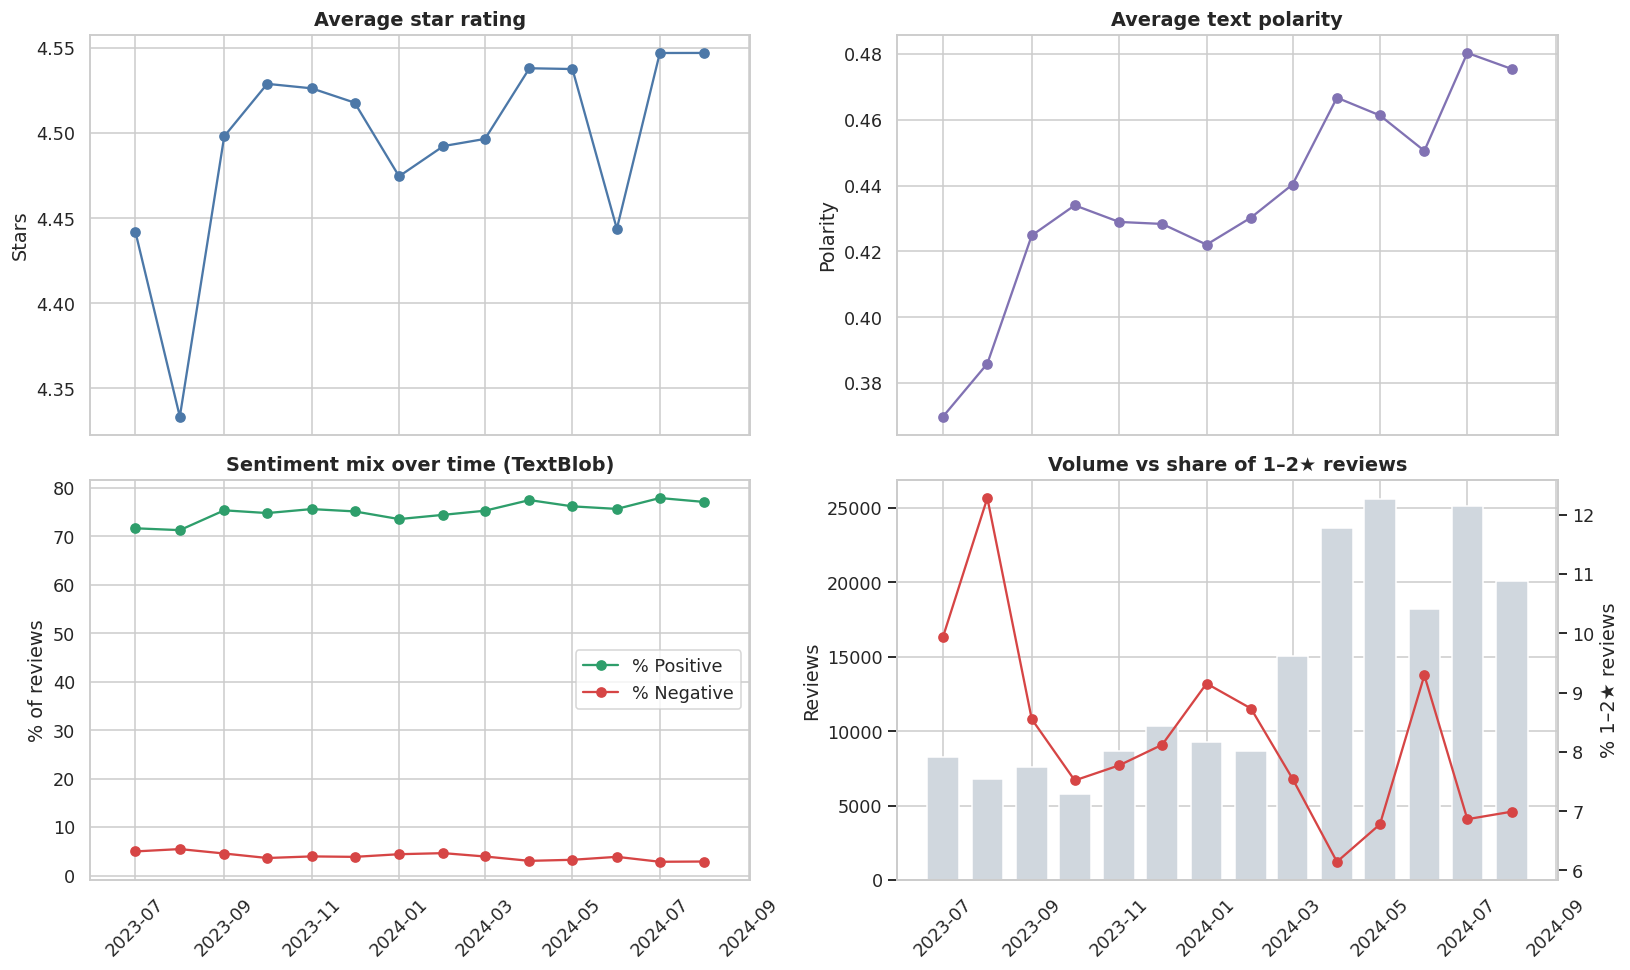

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)

# (1) Average rating
axes[0, 0].plot(monthly.index, monthly["avg_rating"], marker="o", color="#4c78a8")
axes[0, 0].set_title("Average star rating"); axes[0, 0].set_ylabel("Stars")

# (2) Average polarity
axes[0, 1].plot(monthly.index, monthly["avg_polarity"], marker="o", color="#8172b3")
axes[0, 1].set_title("Average text polarity"); axes[0, 1].set_ylabel("Polarity")

# (3) Share positive vs negative (text-based)
axes[1, 0].plot(monthly.index, monthly["pct_positive"], marker="o", color=SENT_COLORS["Positive"], label="% Positive")
axes[1, 0].plot(monthly.index, monthly["pct_negative"], marker="o", color=SENT_COLORS["Negative"], label="% Negative")
axes[1, 0].set_title("Sentiment mix over time (TextBlob)"); axes[1, 0].set_ylabel("% of reviews"); axes[1, 0].legend()

# (4) Share of 1-2★ reviews vs volume
ax4 = axes[1, 1]
ax4.bar(monthly.index, monthly["reviews"], width=22, color="#d0d7de", label="Review volume")
ax4.set_ylabel("Reviews")
ax4b = ax4.twinx()
ax4b.plot(monthly.index, monthly["pct_1_2_star"], color=SENT_COLORS["Negative"], marker="o", label="% 1–2★")
ax4b.set_ylabel("% 1–2★ reviews"); ax4b.grid(False)
ax4.set_title("Volume vs share of 1–2★ reviews")

for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

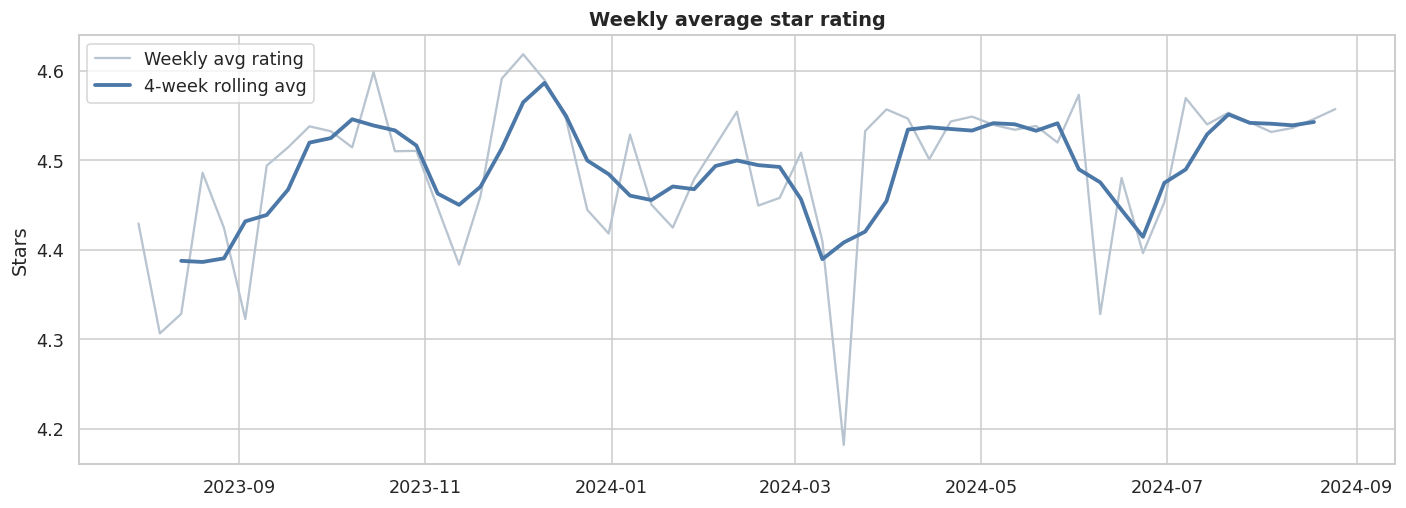

Biggest monthly rating DROP: Aug 2023  (-0.11 stars)
Biggest monthly rating GAIN: Sep 2023  (+0.16 stars)


In [25]:
# Weekly view with a 4-week rolling average -> smoother signal, shows short-lived dips that months hide
weekly = (text_df.set_index("review_date")
                 .resample("W")
                 .agg(avg_rating=("ratings", "mean"), avg_polarity=("polarity", "mean"), reviews=("ratings", "size")))
weekly = weekly[weekly["reviews"] >= 100]            # drop thin weeks (start / end of the data)
weekly["rating_roll4"]   = weekly["avg_rating"].rolling(4, center=True).mean()
weekly["polarity_roll4"] = weekly["avg_polarity"].rolling(4, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(weekly.index, weekly["avg_rating"], color="#b8c4d0", label="Weekly avg rating")
ax.plot(weekly.index, weekly["rating_roll4"], color="#4c78a8", lw=2.5, label="4-week rolling avg")
ax.set_title("Weekly average star rating"); ax.set_ylabel("Stars"); ax.legend()
plt.tight_layout(); plt.show()

# Largest month-over-month changes in rating – useful talking points for the demo
chg = monthly["avg_rating"].diff().dropna()
print(f"Biggest monthly rating DROP: {chg.idxmin():%b %Y}  ({chg.min():+.2f} stars)")
print(f"Biggest monthly rating GAIN: {chg.idxmax():%b %Y}  ({chg.max():+.2f} stars)")

### 8.1 Did the *type* of complaint change over time?
For each month, what share of negative reviews mention each issue theme?

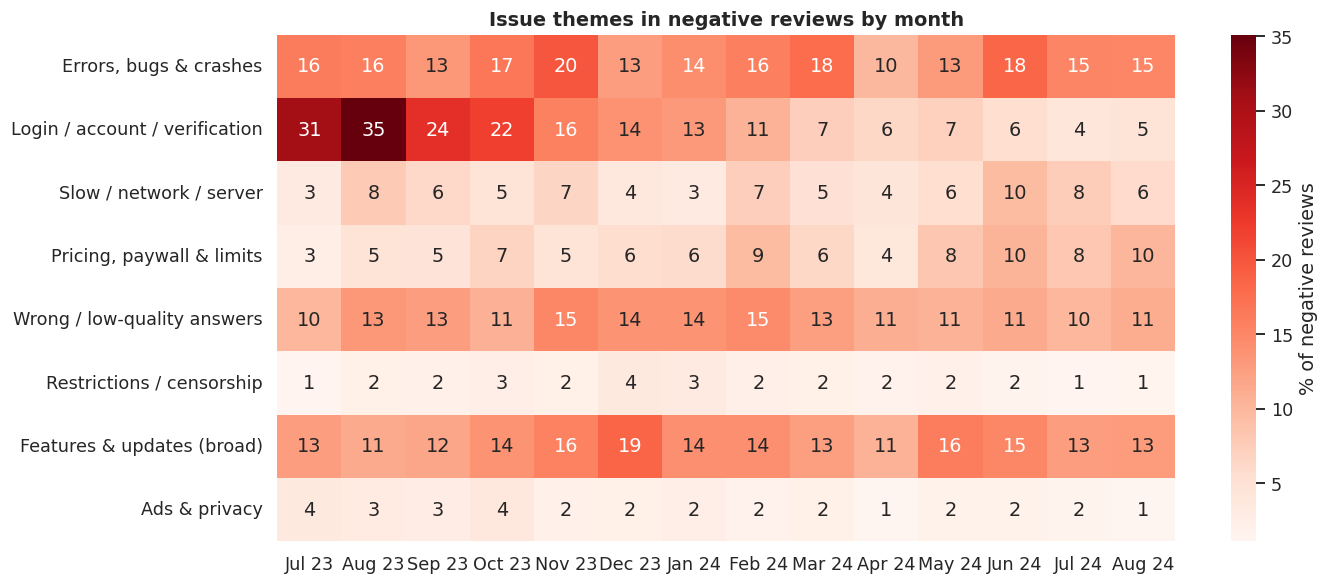

In [26]:
# Share of each month's negative reviews that mention each theme
issue_monthly = neg_df.groupby("month")[list(ISSUE_THEMES)].mean() * 100
neg_per_month = neg_df.groupby("month").size()
issue_monthly = issue_monthly[neg_per_month >= 100]      # need enough negative reviews for stable percentages

plt.figure(figsize=(13, 5.5))
sns.heatmap(issue_monthly.T, annot=True, fmt=".0f", cmap="Reds",
            xticklabels=[d.strftime("%b %y") for d in issue_monthly.index],
            cbar_kws={"label": "% of negative reviews"})
plt.title("Issue themes in negative reviews by month")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.show()

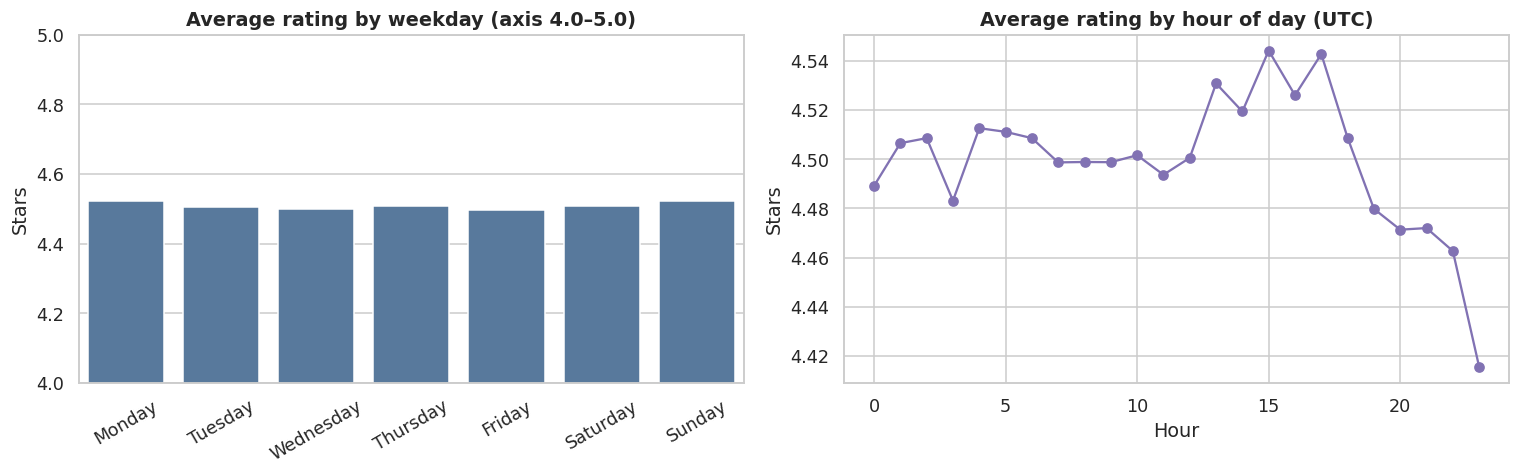

In [27]:
# Day-of-week and hour-of-day patterns (are there times when reviews skew more negative?)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = text_df.groupby("weekday")["ratings"].mean().reindex(order)
sns.barplot(x=dow.index, y=dow.values, color="#4c78a8", ax=axes[0])
axes[0].set_ylim(4.0, 5.0); axes[0].set_title("Average rating by weekday (axis 4.0–5.0)")
axes[0].set_ylabel("Stars"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=30)

hr = text_df.groupby("hour")["ratings"].mean()
axes[1].plot(hr.index, hr.values, marker="o", color="#8172b3")
axes[1].set_title("Average rating by hour of day (UTC)"); axes[1].set_xlabel("Hour"); axes[1].set_ylabel("Stars")
plt.tight_layout(); plt.show()

## 9. Key Metrics Summary
One cell that recomputes the headline numbers – handy for the demo opening / closing slide.

In [28]:
n_total   = len(df)
n_text    = len(text_df)
summary = pd.Series({
    "Reviews analysed (after cleaning)":      f"{n_total:,}",
    "Reviews with text":                       f"{n_text:,}",
    "Period covered":                          f"{df['review_date'].min():%b %Y} – {df['review_date'].max():%b %Y}",
    "Average rating":                          f"{df['ratings'].mean():.2f} / 5",
    "% 4–5★":                                  f"{(df['ratings']>=4).mean()*100:.1f}%",
    "% 1–2★":                                  f"{(df['ratings']<=2).mean()*100:.1f}%",
    "Text sentiment: Positive / Neutral / Negative":
        " / ".join(f"{text_df['sentiment'].value_counts(normalize=True)[c]*100:.1f}%" for c in SENT_ORDER),
    "Mean polarity":                           f"{text_df['polarity'].mean():.3f}",
    "Mean subjectivity":                       f"{text_df['subjectivity'].mean():.3f}",
    "Rating vs polarity (Spearman)":           f"{corr:.2f}",
    "Median words: 1–2★ vs 4–5★":              f"{text_df[text_df.ratings<=2]['word_count'].median():.0f} vs {text_df[text_df.ratings>=4]['word_count'].median():.0f}",
    "#1 complaint theme":                      f"{issue_share.index[-1]} ({issue_share.iloc[-1]:.1f}% of negatives)",
    "#2 complaint theme":                      f"{issue_share.index[-2]} ({issue_share.iloc[-2]:.1f}% of negatives)",
    "#3 complaint theme":                      f"{issue_share.index[-3]} ({issue_share.iloc[-3]:.1f}% of negatives)",
})
summary.to_frame("Value")

,Value
Reviews analysed (after cleaning),"193,154"
Reviews with text,"193,148"
Period covered,Jul 2023 – Aug 2024
Average rating,4.51 / 5
% 4–5★,88.1%
% 1–2★,7.8%
Text sentiment: Positive / Neutral / Negative,75.8% / 20.6% / 3.6%
Mean polarity,0.448
Mean subjectivity,0.517
Rating vs polarity (Spearman),0.25
